## HW5 #4a

In [ ]:
# Import packages and data, create DF of Obs_Node.out

import pandas as pd
import matplotlib.pyplot as plt

rows = []

with open("Obs_Node.out", "r") as f:
    for line in f:
        stripped = line.strip()
        if not stripped:
            continue
        
        parts = stripped.split()
        
        # keep only rows with exactly 4 values that can all be read as floats
        if len(parts) == 4:
            try:
                row = [float(x) for x in parts]
                rows.append(row)
            except ValueError:
                pass

df_obs = pd.DataFrame(rows, columns=["time_s", "h_cm", "theta", "flux_obs_cm_s"])
df_obs

,time_s,h_cm,theta,flux_obs_cm_s
0,1.0,-1.00,0.4286,-0.007600
1,10.0,-1.00,0.4286,-0.007600
2,50.0,-1.02,0.4285,-0.007560
3,100.0,-1.18,0.4278,-0.007320
4,250.0,-1.87,0.4228,-0.006310
5,500.0,-2.78,0.4100,-0.004890
6,1000.0,-3.96,0.3832,-0.003190
7,2000.0,-5.44,0.3398,-0.001680
8,3000.0,-6.27,0.3140,-0.001130
9,4000.0,-7.10,0.2886,-0.000747


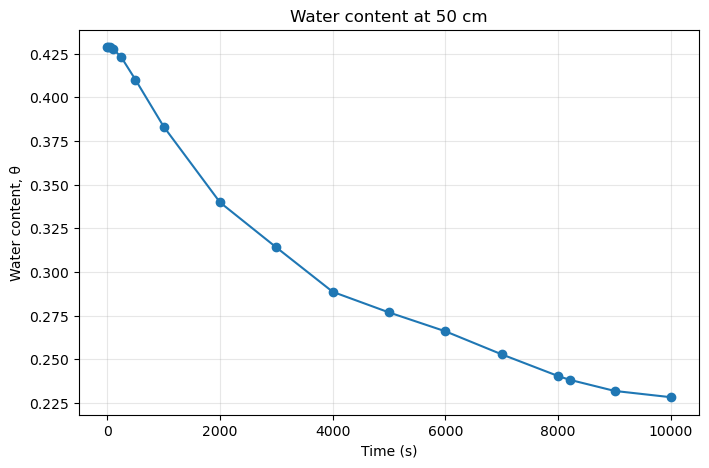

In [7]:
# Plot theta at 50cm as a function of time

plt.figure(figsize=(8,5))
plt.plot(df_obs["time_s"], df_obs["theta"], marker="o")
plt.xlabel("Time (s)")
plt.ylabel("Water content, θ")
plt.title("Water content at 50 cm")
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
# Compute bottom flux from mass balance using q = -L * d(theta)/dt

L_cm = 100.0  # column length in cm

df_obs["dtheta_dt"] = df_obs["theta"].diff() / df_obs["time_s"].diff()
df_obs["q_mass_cm_s"] = -L_cm * df_obs["dtheta_dt"]

df_obs

,time_s,h_cm,theta,flux_obs_cm_s,dtheta_dt,q_mass_balance_cm_s,q_mass_cm_s
0,1.0,-1.00,0.4286,-0.007600,NaN,NaN,NaN
1,10.0,-1.00,0.4286,-0.007600,0.000000,-0.000000,-0.000000
2,50.0,-1.02,0.4285,-0.007560,-0.000002,0.000250,0.000250
3,100.0,-1.18,0.4278,-0.007320,-0.000014,0.001400,0.001400
4,250.0,-1.87,0.4228,-0.006310,-0.000033,0.003333,0.003333
5,500.0,-2.78,0.4100,-0.004890,-0.000051,0.005120,0.005120
6,1000.0,-3.96,0.3832,-0.003190,-0.000054,0.005360,0.005360
7,2000.0,-5.44,0.3398,-0.001680,-0.000043,0.004340,0.004340
8,3000.0,-6.27,0.3140,-0.001130,-0.000026,0.002580,0.002580
9,4000.0,-7.10,0.2886,-0.000747,-0.000025,0.002540,0.002540


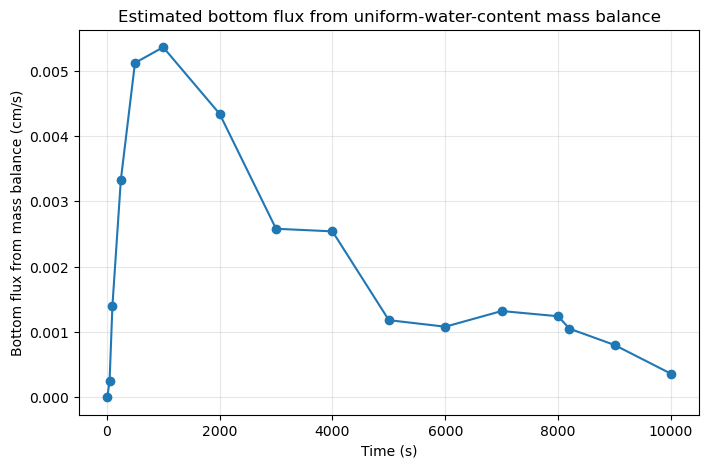

In [12]:
# Plot the mass-balance estimate of bottom flux versus time

plt.figure(figsize=(8,5))
plt.plot(df_obs["time_s"], df_obs["q_mass_cm_s"], marker="o")
plt.xlabel("Time (s)")
plt.ylabel("Bottom flux from mass balance (cm/s)")
plt.title("Estimated bottom flux from uniform-water-content mass balance")
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
# Read Balance.out and create a dataframe of HYDRUS water-balance results

import re

records = []
current = {}

with open("Balance.out", "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue

        if line.startswith("Time"):
            nums = re.findall(r"[-+]?\d*\.?\d+(?:[Ee][-+]?\d+)?", line)
            if nums:
                if "time_s" in current and "bot_flux_cm_s" in current:
                    records.append(current)
                current = {"time_s": float(nums[-1])}

        elif line.startswith("W-volume"):
            nums = re.findall(r"[-+]?\d*\.?\d+(?:[Ee][-+]?\d+)?", line)
            if nums:
                current["w_volume_cm"] = float(nums[-1])

        elif line.startswith("Top Flux"):
            nums = re.findall(r"[-+]?\d*\.?\d+(?:[Ee][-+]?\d+)?", line)
            if nums:
                current["top_flux_cm_s"] = float(nums[-1])

        elif line.startswith("Bot Flux"):
            nums = re.findall(r"[-+]?\d*\.?\d+(?:[Ee][-+]?\d+)?", line)
            if nums:
                current["bot_flux_cm_s"] = float(nums[-1])

        elif line.startswith("WatBalT"):
            nums = re.findall(r"[-+]?\d*\.?\d+(?:[Ee][-+]?\d+)?", line)
            if nums:
                current["watbalT"] = float(nums[-1])

        elif line.startswith("WatBalR"):
            nums = re.findall(r"[-+]?\d*\.?\d+(?:[Ee][-+]?\d+)?", line)
            if nums:
                current["watbalR_percent"] = float(nums[-1])

if "time_s" in current and "bot_flux_cm_s" in current:
    records.append(current)

df_bal = pd.DataFrame(records)
df_bal

,time_s,w_volume_cm,top_flux_cm_s,bot_flux_cm_s,watbalT,watbalR_percent
0,0.0,42.860,-0.007603,-0.007603,NaN,NaN
1,1.0,42.852,-0.003373,-0.007603,7.348100e-07,0.010
2,10.0,42.784,-0.001174,-0.007603,-4.120200e-06,0.005
3,50.0,42.480,-0.000472,-0.007603,3.629900e-05,0.010
4,100.0,42.100,-0.000268,-0.007598,3.868300e-05,0.005
5,250.0,40.981,-0.000110,-0.007345,3.886200e-05,0.002
6,500.0,39.266,-0.000056,-0.006560,2.646400e-05,0.001
7,1000.0,36.440,-0.000025,-0.005080,3.528600e-05,0.001
8,2000.0,32.455,-0.000010,-0.003262,3.624000e-05,0.000
9,3000.0,29.801,-0.000006,-0.002304,3.814700e-05,0.000


In [14]:
# Merge the observation-node data and water-balance data by time

df = pd.merge(df_obs, df_bal, on="time_s", how="inner")
df

,time_s,h_cm,theta,flux_obs_cm_s,dtheta_dt,q_mass_balance_cm_s,q_mass_cm_s,w_volume_cm,top_flux_cm_s,bot_flux_cm_s,watbalT,watbalR_percent
0,1.0,-1.00,0.4286,-0.007600,NaN,NaN,NaN,42.852,-0.003373,-0.007603,7.348100e-07,0.010
1,10.0,-1.00,0.4286,-0.007600,0.000000,-0.000000,-0.000000,42.784,-0.001174,-0.007603,-4.120200e-06,0.005
2,50.0,-1.02,0.4285,-0.007560,-0.000002,0.000250,0.000250,42.480,-0.000472,-0.007603,3.629900e-05,0.010
3,100.0,-1.18,0.4278,-0.007320,-0.000014,0.001400,0.001400,42.100,-0.000268,-0.007598,3.868300e-05,0.005
4,250.0,-1.87,0.4228,-0.006310,-0.000033,0.003333,0.003333,40.981,-0.000110,-0.007345,3.886200e-05,0.002
5,500.0,-2.78,0.4100,-0.004890,-0.000051,0.005120,0.005120,39.266,-0.000056,-0.006560,2.646400e-05,0.001
6,1000.0,-3.96,0.3832,-0.003190,-0.000054,0.005360,0.005360,36.440,-0.000025,-0.005080,3.528600e-05,0.001
7,2000.0,-5.44,0.3398,-0.001680,-0.000043,0.004340,0.004340,32.455,-0.000010,-0.003262,3.624000e-05,0.000
8,3000.0,-6.27,0.3140,-0.001130,-0.000026,0.002580,0.002580,29.801,-0.000006,-0.002304,3.814700e-05,0.000
9,4000.0,-7.10,0.2886,-0.000747,-0.000025,0.002540,0.002540,27.862,-0.000004,-0.001633,3.624000e-05,0.000


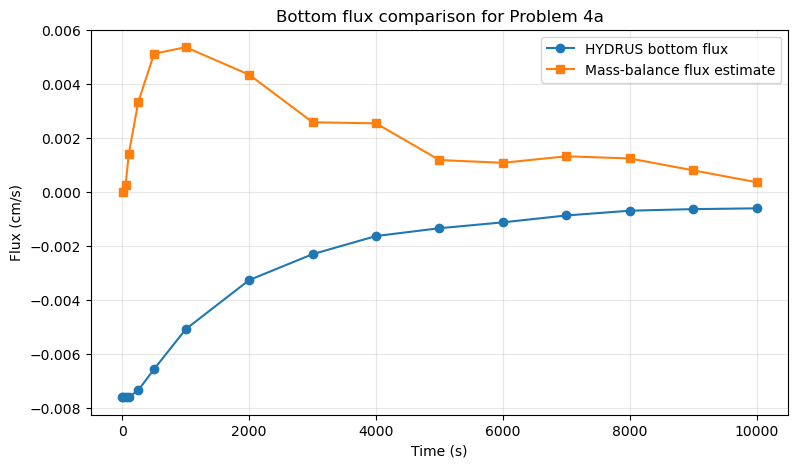

In [15]:
# Plot HYDRUS bottom flux and the mass-balance flux estimate together

plt.figure(figsize=(9,5))

plt.plot(df["time_s"], df["bot_flux_cm_s"], marker="o", label="HYDRUS bottom flux")
plt.plot(df["time_s"], df["q_mass_cm_s"], marker="s", label="Mass-balance flux estimate")

plt.xlabel("Time (s)")
plt.ylabel("Flux (cm/s)")
plt.title("Bottom flux comparison for Problem 4a")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

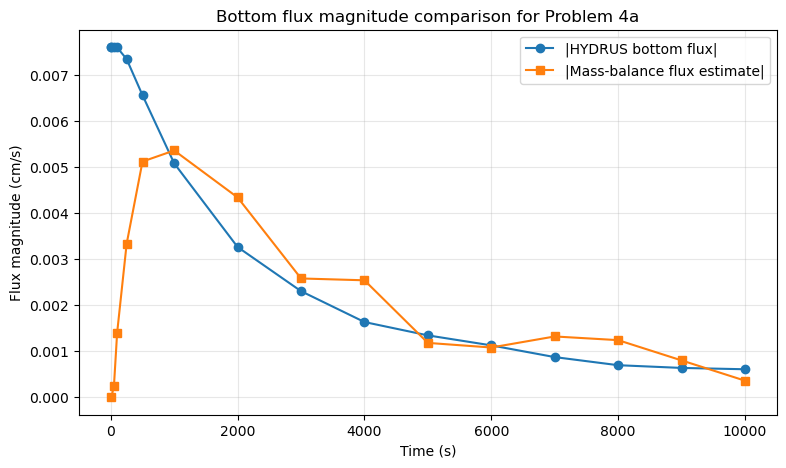

In [16]:
# Plot the magnitudes of the HYDRUS and mass-balance fluxes for easier comparison

plt.figure(figsize=(9,5))

plt.plot(df["time_s"], abs(df["bot_flux_cm_s"]), marker="o", label="|HYDRUS bottom flux|")
plt.plot(df["time_s"], abs(df["q_mass_cm_s"]), marker="s", label="|Mass-balance flux estimate|")

plt.xlabel("Time (s)")
plt.ylabel("Flux magnitude (cm/s)")
plt.title("Bottom flux magnitude comparison for Problem 4a")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [17]:
# Compute the third flux curve using the HW4 5(c) unit-gradient drainage approximation q ≈ K(theta)

theta_r = 0.045
theta_s = 0.43
n_vg = 2.68
m_vg = 1 - 1 / n_vg
l_vg = 0.5
Ks_cm_s = 0.00825  # cm/s

# Effective saturation from observed theta
Se = (df["theta"] - theta_r) / (theta_s - theta_r)

# Keep Se in the physically valid range [0, 1]
Se = Se.clip(lower=0.0, upper=1.0)

# van Genuchten-Mualem unsaturated conductivity
K_theta_cm_s = Ks_cm_s * (Se ** l_vg) * (1 - (1 - Se ** (1 / m_vg)) ** m_vg) ** 2

# Under unit-gradient drainage, downward flux magnitude is approximately K(theta)
df["q_unitgrad_cm_s"] = K_theta_cm_s

df[["time_s", "theta", "q_unitgrad_cm_s"]]

,time_s,theta,q_unitgrad_cm_s
0,1.0,0.4286,0.007596
1,10.0,0.4286,0.007596
2,50.0,0.4285,0.007567
3,100.0,0.4278,0.007384
4,250.0,0.4228,0.006470
5,500.0,0.4100,0.005041
6,1000.0,0.3832,0.003274
7,2000.0,0.3398,0.001699
8,3000.0,0.3140,0.001137
9,4000.0,0.2886,0.000749


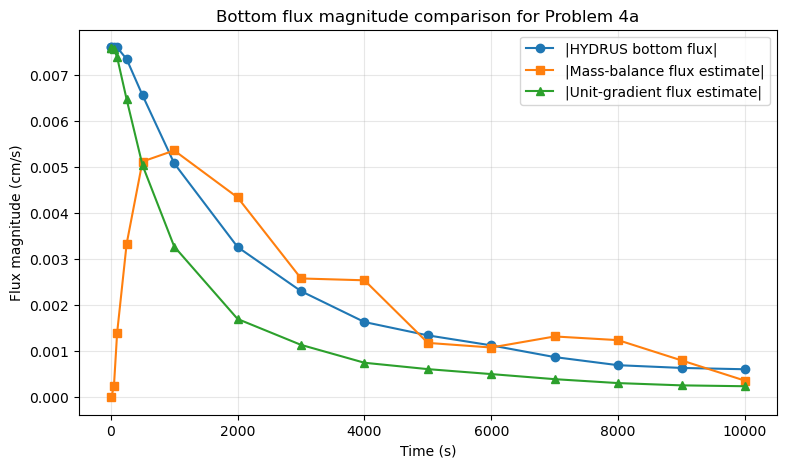

In [18]:
# Plot all three flux magnitudes together for Problem 4a

plt.figure(figsize=(9,5))

plt.plot(df["time_s"], abs(df["bot_flux_cm_s"]), marker="o", label="|HYDRUS bottom flux|")
plt.plot(df["time_s"], abs(df["q_mass_cm_s"]), marker="s", label="|Mass-balance flux estimate|")
plt.plot(df["time_s"], abs(df["q_unitgrad_cm_s"]), marker="^", label="|Unit-gradient flux estimate|")

plt.xlabel("Time (s)")
plt.ylabel("Flux magnitude (cm/s)")
plt.title("Bottom flux magnitude comparison for Problem 4a")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## HW5 #4b
### Create inferred K(theta) values from the two flux estimates from Part 4a

In [20]:
# Create inferred K(theta) values from the mass-balance and HYDRUS fluxes

df["K_from_mass_cm_s"] = abs(df["q_mass_cm_s"])
df["K_from_hydrus_cm_s"] = abs(df["bot_flux_cm_s"])

df[["time_s", "theta", "K_from_mass_cm_s", "K_from_hydrus_cm_s"]]

,time_s,theta,K_from_mass_cm_s,K_from_hydrus_cm_s
0,1.0,0.4286,NaN,0.007603
1,10.0,0.4286,0.000000,0.007603
2,50.0,0.4285,0.000250,0.007603
3,100.0,0.4278,0.001400,0.007598
4,250.0,0.4228,0.003333,0.007345
5,500.0,0.4100,0.005120,0.006560
6,1000.0,0.3832,0.005360,0.005080
7,2000.0,0.3398,0.004340,0.003262
8,3000.0,0.3140,0.002580,0.002304
9,4000.0,0.2886,0.002540,0.001633


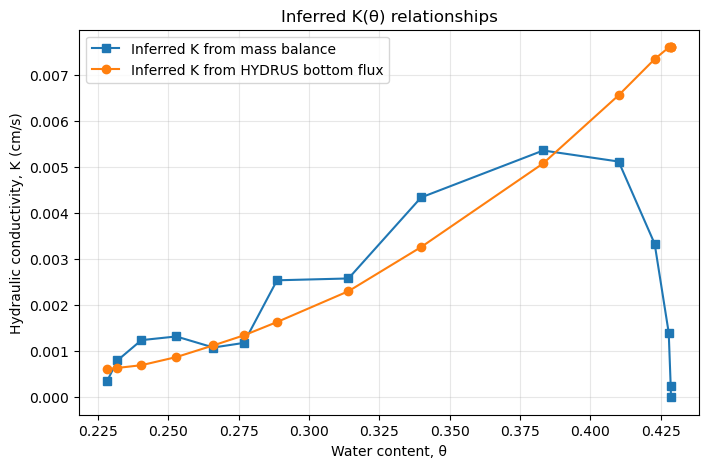

In [21]:
# Plot the two inferred K(theta) datasets

plt.figure(figsize=(8,5))
plt.plot(df["theta"], df["K_from_mass_cm_s"], marker="s", linestyle="-", label="Inferred K from mass balance")
plt.plot(df["theta"], df["K_from_hydrus_cm_s"], marker="o", linestyle="-", label="Inferred K from HYDRUS bottom flux")

plt.xlabel("Water content, θ")
plt.ylabel("Hydraulic conductivity, K (cm/s)")
plt.title("Inferred K(θ) relationships")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [23]:
# Compute the true K(theta) curve for the default sand using the van Genuchten-Mualem model

import numpy as np

theta_r = 0.045
theta_s = 0.43
n_vg = 2.68
m_vg = 1 - 1/n_vg
l_vg = 0.5
Ks_cm_s = 0.00825

theta_curve = np.linspace(theta_r, theta_s, 400)

Se_curve = (theta_curve - theta_r) / (theta_s - theta_r)
Se_curve = np.clip(Se_curve, 0.0, 1.0)

K_true_curve = Ks_cm_s * (Se_curve ** l_vg) * (1 - (1 - Se_curve ** (1 / m_vg)) ** m_vg) ** 2

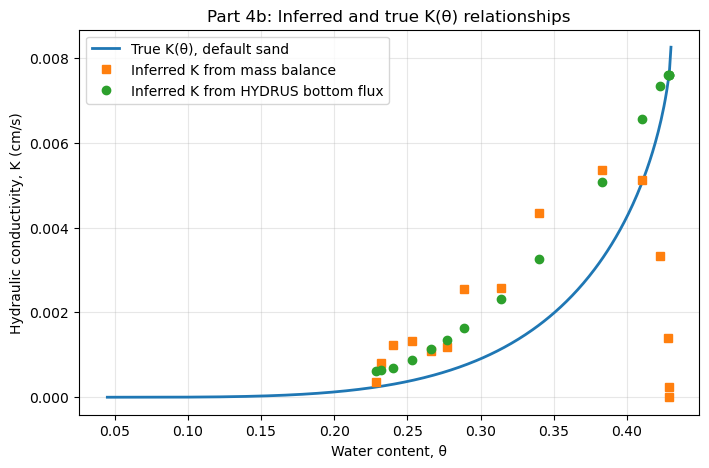

In [24]:
# Plot inferred K(theta) values together with the true default-sand K(theta) curve

plt.figure(figsize=(8,5))

plt.plot(theta_curve, K_true_curve, linewidth=2, label="True K(θ), default sand")
plt.plot(df["theta"], df["K_from_mass_cm_s"], marker="s", linestyle="None", label="Inferred K from mass balance")
plt.plot(df["theta"], df["K_from_hydrus_cm_s"], marker="o", linestyle="None", label="Inferred K from HYDRUS bottom flux")

plt.xlabel("Water content, θ")
plt.ylabel("Hydraulic conductivity, K (cm/s)")
plt.title("Part 4b: Inferred and true K(θ) relationships")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

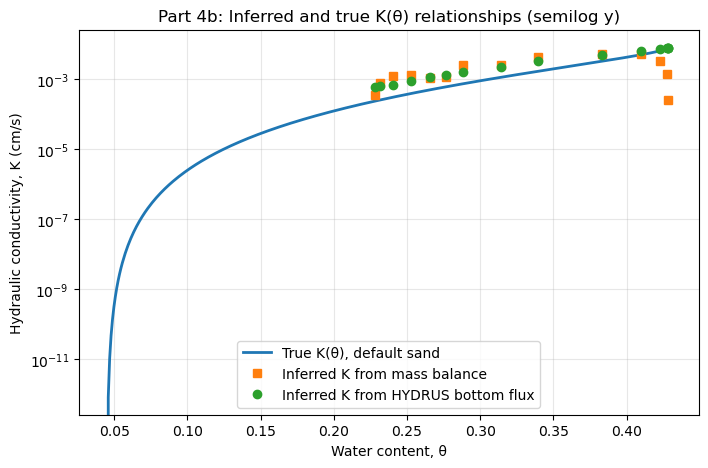

In [25]:
# Make a semilog-y plot for easier comparison over a wide range of K values

plt.figure(figsize=(8,5))

plt.semilogy(theta_curve, K_true_curve, linewidth=2, label="True K(θ), default sand")
plt.semilogy(df["theta"], df["K_from_mass_cm_s"], marker="s", linestyle="None", label="Inferred K from mass balance")
plt.semilogy(df["theta"], df["K_from_hydrus_cm_s"], marker="o", linestyle="None", label="Inferred K from HYDRUS bottom flux")

plt.xlabel("Water content, θ")
plt.ylabel("Hydraulic conductivity, K (cm/s)")
plt.title("Part 4b: Inferred and true K(θ) relationships (semilog y)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## HW5 #4c

In [26]:
# Import curve-fitting tools for Part 4c

from scipy.optimize import curve_fit
import numpy as np

In [27]:
# Fit the Mualem-van Genuchten conductivity model to the K(theta) values inferred from the HYDRUS bottom flux

# Fixed parameters from the homework
Ks_cm_s = 0.00825
theta_r = 0.045

# For this fit, we will use theta_s = default sand value from the forward model
theta_s = 0.43
l_vg = 0.5

# Use the K(theta) values inferred from the HYDRUS bottom flux
theta_fit = df["theta"].values
K_fit = df["K_from_hydrus_cm_s"].values

# Keep only positive K values and theta values strictly between theta_r and theta_s
mask = (K_fit > 0) & (theta_fit > theta_r) & (theta_fit < theta_s)

theta_fit_clean = theta_fit[mask]
K_fit_clean = K_fit[mask]

def K_model_from_theta(theta, n):
    m = 1 - 1 / n
    Se = (theta - theta_r) / (theta_s - theta_r)
    Se = np.clip(Se, 1e-10, 1.0)
    K = Ks_cm_s * (Se ** l_vg) * (1 - (1 - Se ** (1 / m)) ** m) ** 2
    return K

# Initial guess for n
p0 = [2.0]

# Fit n
popt_K, pcov_K = curve_fit(
    K_model_from_theta,
    theta_fit_clean,
    K_fit_clean,
    p0=p0,
    bounds=(1.01, 10.0)
)

n_fit_from_K = popt_K[0]
n_fit_from_K

np.float64(5.454223384044676)

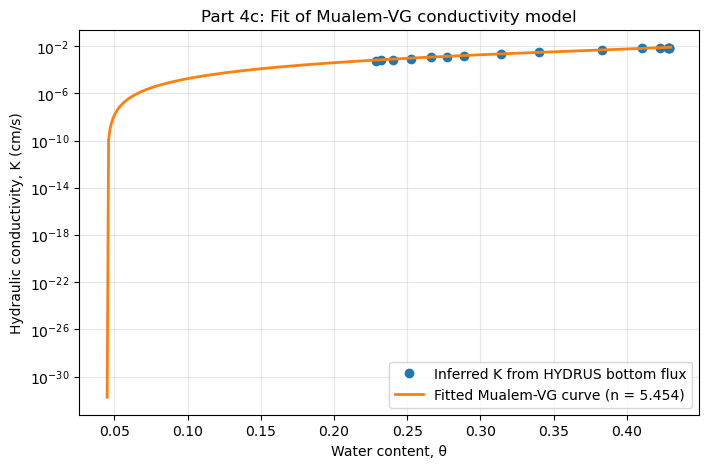

In [28]:
# Plot the fitted conductivity curve together with the inferred K(theta) points from the HYDRUS bottom flux

theta_plot = np.linspace(theta_r, theta_s, 400)
K_fit_curve = K_model_from_theta(theta_plot, n_fit_from_K)

plt.figure(figsize=(8,5))
plt.semilogy(theta_fit_clean, K_fit_clean, "o", label="Inferred K from HYDRUS bottom flux")
plt.semilogy(theta_plot, K_fit_curve, "-", linewidth=2, label=f"Fitted Mualem-VG curve (n = {n_fit_from_K:.3f})")

plt.xlabel("Water content, θ")
plt.ylabel("Hydraulic conductivity, K (cm/s)")
plt.title("Part 4c: Fit of Mualem-VG conductivity model")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [29]:
# Fit the van Genuchten retention model to paired pressure head and water content data at the observation node

# Use paired pressure head and water content data from the observation node
h_data = df["h_cm"].values
theta_data = df["theta"].values

# Keep only unsaturated points (h < 0) and physically valid theta
mask_ret = (h_data < 0) & (theta_data > theta_r) & (theta_data <= theta_s)

h_fit = h_data[mask_ret]
theta_ret_fit = theta_data[mask_ret]

def theta_model_from_h(h, alpha, n):
    m = 1 - 1 / n
    abs_term = np.abs(alpha * h) ** n
    theta = theta_r + (theta_s - theta_r) / ((1 + abs_term) ** m)
    return theta

# Initial guesses for alpha and n
p0_ret = [0.1, 2.0]

# Fit alpha and n
popt_ret, pcov_ret = curve_fit(
    theta_model_from_h,
    h_fit,
    theta_ret_fit,
    p0=p0_ret,
    bounds=([1e-4, 1.01], [10.0, 10.0])
)

alpha_fit = popt_ret[0]
n_fit_from_ret = popt_ret[1]

alpha_fit, n_fit_from_ret

(np.float64(0.14505435851416112), np.float64(2.662578846484425))

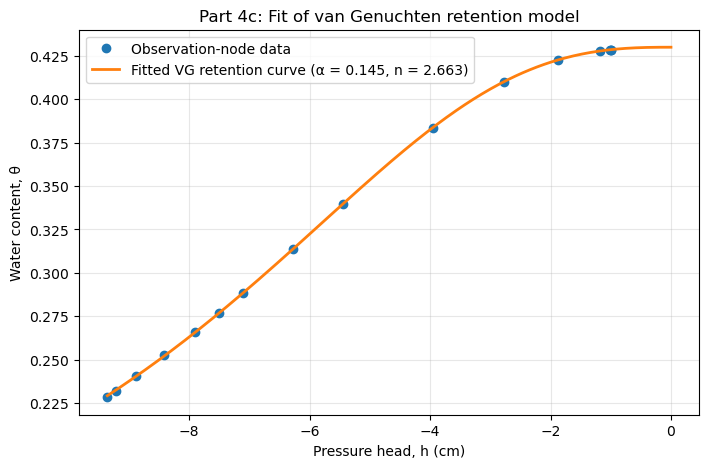

In [30]:
# Plot the fitted van Genuchten retention curve together with the paired observation-node data

h_plot = np.linspace(np.min(h_fit), -1e-6, 400)
theta_ret_curve = theta_model_from_h(h_plot, alpha_fit, n_fit_from_ret)

plt.figure(figsize=(8,5))
plt.plot(h_fit, theta_ret_fit, "o", label="Observation-node data")
plt.plot(h_plot, theta_ret_curve, "-", linewidth=2, label=f"Fitted VG retention curve (α = {alpha_fit:.3f}, n = {n_fit_from_ret:.3f})")

plt.xlabel("Pressure head, h (cm)")
plt.ylabel("Water content, θ")
plt.title("Part 4c: Fit of van Genuchten retention model")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [31]:
# Print the fitted parameter values and compare them with the forward-model values

alpha_true = 0.145
n_true = 2.68

print(f"Best-fit n from K(theta) fit: {n_fit_from_K:.4f}")
print(f"Best-fit alpha from theta(h) fit: {alpha_fit:.4f} cm^-1")
print(f"Best-fit n from theta(h) fit: {n_fit_from_ret:.4f}")
print()
print(f"Forward-model alpha: {alpha_true:.4f} cm^-1")
print(f"Forward-model n: {n_true:.4f}")

Best-fit n from K(theta) fit: 5.4542
Best-fit alpha from theta(h) fit: 0.1451 cm^-1
Best-fit n from theta(h) fit: 2.6626

Forward-model alpha: 0.1450 cm^-1
Forward-model n: 2.6800


## HW5 #5